In [1]:
##Experiment polynomial regresion on auto MPG dataset
#Prediction of mpg using Engine Displacement
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#load auto MPG dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

In [4]:
df=pd.read_csv(url)

In [5]:
#Display 1st 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
#seperate input and output
x=df[['displacement']]
y=df['mpg']
#check missing values
print("Missing value in ",x.isnull().sum())
print("missing values in mpg ",y.isnull().sum())

Missing value in  displacement    0
dtype: int64
missing values in mpg  0


In [7]:
#remove rows contain missing values
data=df[['displacement','mpg']].dropna()
#update input and output

x=df[['displacement']]
y=df['mpg']

#display the selected data
print("Features")
print(x.head())

print("\nTarget")
print(y.head())

Features
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


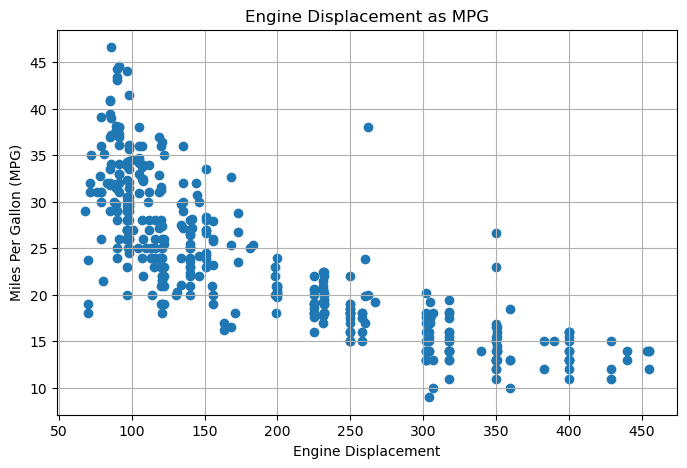

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(x,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Engine Displacement as MPG")

plt.grid(True)
plt.show()

In [9]:
#split the dataset

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    )

print("Training sample:",len(x_train))
print("Testing sample:",len(y_train))

Training sample: 318
Testing sample: 318


In [10]:
#create LR model 
linear_model = LinearRegression()
#train the model
linear_model.fit(x_train,y_train)
#predict the test data
y_pred_linear=linear_model.predict(x_test)

In [11]:
#calculate MSE

mse_linear = mean_squared_error(y_test,y_pred_linear)

#calculate R-squared

r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression Result")
print("------------------------")
print("MSE:",mse_linear)
print("R-squared:",r2_linear)

Linear Regression Result
------------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [12]:
#store results
results=[]

#store polynomial models for plotting
polynomial_models={}

#Add Linear Regression results
results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
    })

In [13]:
#Try polynomial degrees from 2 to 5
for degree in range(2,6):
    #create polynomial features
    poly=PolynomialFeatures(degree=degree)
    #Transform trqing and testing data
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    #Create Linear Regression model

    poly_model=LinearRegression()

    #train polynomial regression model

    poly_model.fit(x_train_poly,y_train)

    #make prediction

    y_pred_poly = poly_model.predict(x_test_poly)

    #calculate evaluation metrics

    mse=mean_squared_error(y_test,y_pred_poly)

    r2=r2_score(y_test,y_pred_poly)

    #store result
    results.append({

    'Model':'Polynomial Regression',
    'Degree':degree,
    'MSE': mse,
    'R-squared':r2
    })
    #store model and polynomial transformer

    polynomial_models[degree]={

    'poly':poly,
    'model':poly_model }

In [14]:
#convert results into dataframe
results_df=pd.DataFrame(results)

#display result
results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


In [15]:
#create smooth X values for plotting

x_plot=pd.DataFrame({
    'displacement':np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300)
})

#create figure
plt.figure(figsize=(10,6))



<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

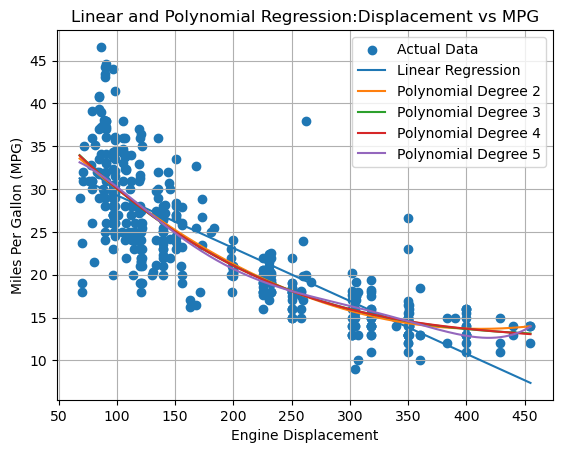

In [16]:
#plot actual data
plt.scatter(
    x['displacement'],
    y,
    label = 'Actual Data'
)
#----------------------
#plot linear regression
#----------------------

y_plot_linear = linear_model.predict(x_plot)

plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)
#------------------------
for degree in range(2,6):
    #retrive stored transformer and model
    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']
    #transform smooth x values
    x_plot_poly=poly.transform(x_plot)
    #predict
    y_plot_poly=poly_model.predict(x_plot_poly)
    #plot curve
    plt.plot(
    x_plot['displacement'],
    y_plot_poly,
    label=f"Polynomial Degree {degree}"
    )


#--------------
#plot formatting
#--------------

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Linear and Polynomial Regression:Displacement vs MPG')
plt.legend()
plt.grid(True)
plt.show()

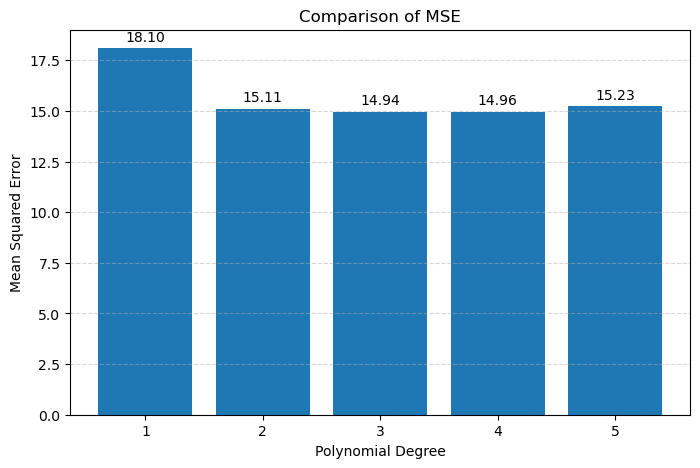

In [17]:
plt.figure(figsize=(8,5))
bars =plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

#Add labels above bars

plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

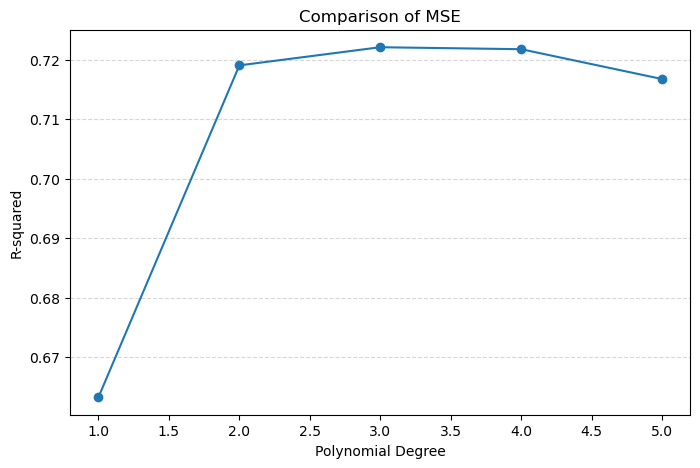

In [18]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()